In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("../data/DataWithDescriptors.csv")
cation_pka=pd.read_excel("../data/pkacation.xlsx")
anion_pka=pd.read_excel("../data/pkaanion.xlsx")
print(df.shape)
print(cation_pka.shape)
print(anion_pka.shape)

(5349, 444)
(77, 2)
(80, 2)


In [4]:
df["IL NAME"] = (
    
    df["CATION NAME"].astype(str) +
    " " +
    df["ANION NAME"].astype(str) )

In [5]:
ffv=pd.read_csv("../outputs/tables/unique_ionic_liquids_with_ffv.csv")

In [6]:
df = df.merge(ffv[["IL NAME", "FFV"]],on="IL NAME",how="left")

In [7]:
cation_pka=cation_pka.rename(columns={ "CATION": 'CATION NAME' })

In [8]:
anion_pka=anion_pka.rename(columns={"Anion":"ANION NAME"})

In [9]:
df = pd.merge(df,cation_pka,on="CATION NAME",how="left")

In [10]:
df = pd.merge(df,anion_pka,on="ANION NAME",how="left")

In [11]:
df["CATION_pKa"].isnull().sum()

np.int64(0)

In [12]:
df["Anion_pKa"].isnull().sum()

np.int64(0)

In [13]:
df["Delta_pKa"] = df["CATION_pKa"] - df["Anion_pKa"]

C:\Users\BIT\AppData\Local\Temp\ipykernel_1172\3233356666.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Delta_pKa"] = df["CATION_pKa"] - df["Anion_pKa"]


In [14]:
df["Delta_pKa"].describe()

count    5349.000000
mean       27.186790
std         7.859206
min        -4.200000
25%        21.600000
50%        26.300000
75%        34.000000
max        39.000000
Name: Delta_pKa, dtype: float64

In [16]:
known_ffv = df[df["FFV"].notna()].copy()

In [17]:
known_ffv.columns

Index(['Unnamed: 0', 'IL NAME', 'CATION NAME', 'ANION NAME', 'Cation_SMILES',
       'Anion_SMILES', 'Temperature (0 C)', 'Pressure (bar)',
       'CO2 capacity (mol CO2/mol IL)', 'Cation_Family',
       ...
       'An_fr_tetrazole', 'An_fr_thiazole', 'An_fr_thiocyan',
       'An_fr_thiophene', 'An_fr_unbrch_alkane', 'An_fr_urea', 'FFV',
       'CATION_pKa', 'Anion_pKa', 'Delta_pKa'],
      dtype='str', length=448)

In [18]:
x=known_ffv[["Temperature (0 C)","Pressure (bar)","Delta_pKa","FFV"]]

In [19]:
y=known_ffv["CO2 capacity (mol CO2/mol IL)"]

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(X_train.shape,X_test.shape,y_train.shape, y_test.shape)
import xgboost as xgb
model = xgb.XGBRegressor(objective='reg:squarederror',n_estimators=100, random_state=42)
model.fit(X_train,y_train)
y_train_pred=model.predict(X_train)
y_pred=model.predict(X_test)
from sklearn.metrics import(r2_score,mean_absolute_error,mean_squared_error)
r2=r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
train_r2 = r2_score(y_train,y_train_pred)
print("Train R2:", round(train_r2,4))
print("TEST METRICS ARE")
print("R2 :", round(r2,4))
print("MAE :", round(mae,4))
print("RMSE :", round(rmse,4))

(3392, 4) (849, 4) (3392,) (849,)
Train R2: 0.9986
TEST METRICS ARE
R2 : 0.9737
MAE : 0.0317
RMSE : 0.0709


In [21]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model,X_train,y_train,cv=10,scoring="r2",n_jobs=-1)
print("Fold Scores:")
print(cv_scores)
print()
print("Mean CV R2:",round(cv_scores.mean(),4))
print("Std CV R2:",round(cv_scores.std(),4))

Fold Scores:
[0.94733086 0.97416035 0.9725221  0.96780596 0.96601968 0.97903458
 0.97713885 0.97901786 0.88872884 0.97025688]

Mean CV R2: 0.9622
Std CV R2: 0.026


In [22]:
corr_df = df[
    [
        "Temperature (0 C)",
        "Pressure (bar)",
        "CATION_pKa",
        "Anion_pKa",
        "Delta_pKa",
        "FFV",
        "CO2 capacity (mol CO2/mol IL)"
    ]
].corr()

corr_df

,Temperature (0 C),Pressure (bar),CATION_pKa,Anion_pKa,Delta_pKa,FFV,CO2 capacity (mol CO2/mol IL)
Temperature (0 C),1.000000,0.361796,0.022947,-0.037749,0.044114,0.043401,-0.032505
Pressure (bar),0.361796,1.000000,0.058660,-0.019446,0.053671,-0.085553,0.495167
CATION_pKa,0.022947,0.058660,1.000000,0.024425,0.641946,-0.021652,-0.097684
Anion_pKa,-0.037749,-0.019446,0.024425,1.000000,-0.750841,-0.115947,-0.000289
Delta_pKa,0.044114,0.053671,0.641946,-0.750841,1.000000,0.072193,-0.064316
FFV,0.043401,-0.085553,-0.021652,-0.115947,0.072193,1.000000,-0.074025
CO2 capacity (mol CO2/mol IL),-0.032505,0.495167,-0.097684,-0.000289,-0.064316,-0.074025,1.000000


In [23]:
import shap

In [24]:
explainer = shap.TreeExplainer(model)

In [25]:
shap_values = explainer.shap_values(X_test)

In [26]:
print(shap_values.shape)

(849, 4)


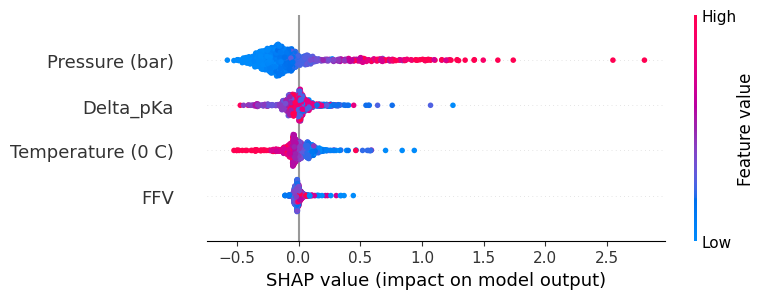

In [27]:
shap.summary_plot(
    shap_values,
    X_test
)

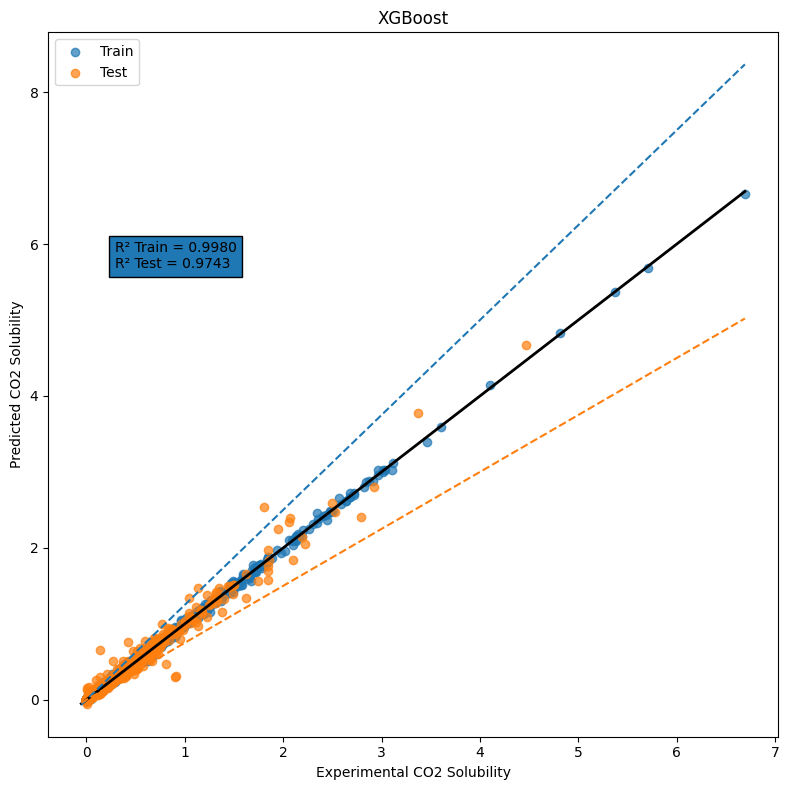

In [28]:
all_values = np.concatenate([
    y_train,
    y_test,
    y_train_pred,
    y_pred
])

xmin = all_values.min()
xmax = all_values.max()

# Perfect prediction line
x_line = np.linspace(xmin, xmax, 100)

# ±25%
upper = x_line * 1.25
lower = x_line * 0.75

plt.figure(figsize=(8,8))

# Train
plt.scatter(
    y_train,
    y_train_pred,
    label="Train",
    alpha=0.7
)

# Test
plt.scatter(
    y_test,
    y_pred,
    label="Test",
    alpha=0.7
)

# Perfect prediction
plt.plot(
    x_line,
    x_line,
    color="black",
    linewidth=2
)

# +25%
plt.plot(
    x_line,
    upper,
    linestyle="--"
)

# -25%
plt.plot(
    x_line,
    lower,
    linestyle="--"
)

plt.xlabel("Experimental CO2 Solubility")
plt.ylabel("Predicted CO2 Solubility")

plt.legend()

plt.text(
    xmin + 0.05*(xmax-xmin),
    xmax - 0.15*(xmax-xmin),
    f"R² Train = {0.998:.4f}\nR² Test = {0.9743:.4f}",
    bbox=dict()
)

plt.title("XGBoost")

plt.tight_layout()

plt.show()

In [29]:
train_error = y_train - y_train_pred
test_error = y_test - y_pred

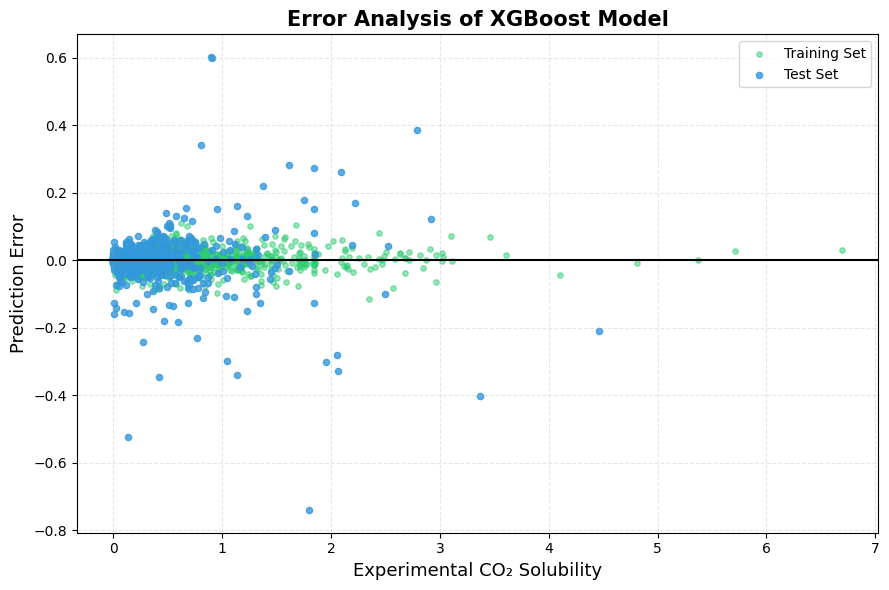

In [30]:
plt.figure(figsize=(9,6))

plt.scatter(
    y_train,
    train_error,
    c="#2ecc71",
    alpha=0.5,
    s=15,
    label="Training Set"
)

plt.scatter(
    y_test,
    test_error,
    c="#3498db",
    alpha=0.8,
    s=20,
    label="Test Set"
)

plt.axhline(
    0,
    color="black",
    linewidth=1.5
)

plt.xlabel(
    "Experimental CO₂ Solubility",
    fontsize=13
)

plt.ylabel(
    "Prediction Error",
    fontsize=13
)

plt.title(
    "Error Analysis of XGBoost Model",
    fontsize=15,
    fontweight="bold"
)

plt.legend()

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

In [31]:
train_error = np.array(train_error).flatten()
test_error = np.array(test_error).flatten()


In [32]:
from scipy.stats import norm

In [33]:
print(train_error.min(), train_error.max())
print(test_error.min(), test_error.max())

-0.11540947585632333 0.11046236834121703
-0.7406315326690673 0.6023731768131256


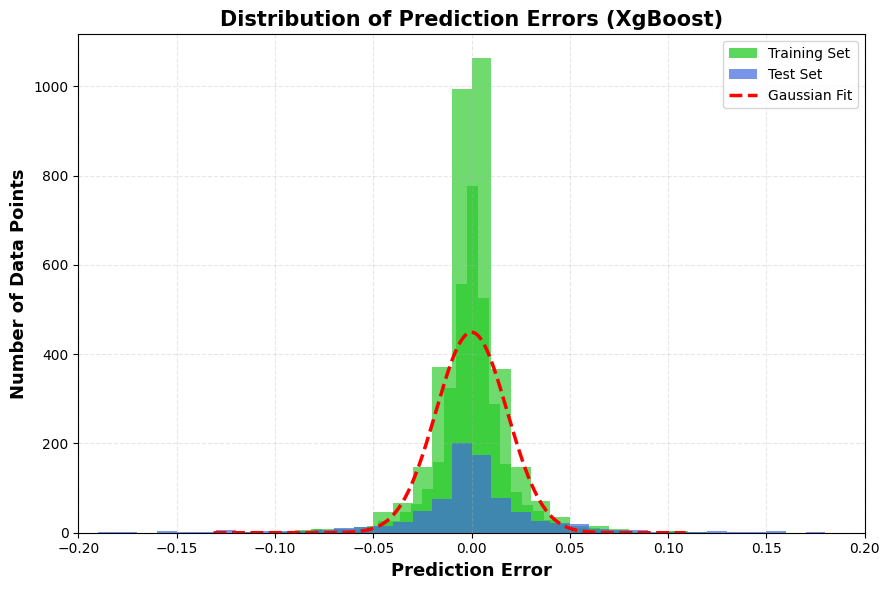

In [36]:
mu_train, sigma_train = norm.fit(train_error)

# Fit Gaussian on test errors
mu_test, sigma_test = norm.fit(test_error)

# Create x values
all_errors = np.concatenate([train_error, test_error])

xmin = np.percentile(all_errors, 0.5)
xmax = np.percentile(all_errors, 99.5)

x = np.linspace(xmin, xmax, 500)

# Plot
plt.figure(figsize=(9,6))

# Training histogram
plt.hist(
    train_error,
    bins=40,
    color="limegreen",
    alpha=0.8,
    label="Training Set"
)

# Test histogram
plt.hist(
    train_error,
    bins=40,
    range=(-0.2,0.2),
    color="limegreen",
    alpha=0.7,
    
)

plt.hist(
    test_error,
    bins=40,
    range=(-0.2,0.2),
    color="royalblue",
    alpha=0.7,
    label="Test Set"
)

# Gaussian curves
plt.plot(
    x,
    norm.pdf(x, mu_train, sigma_train) * len(train_error) * (xmax-xmin)/40,
    'r--',
    linewidth=2.5,
    label="Gaussian Fit"
)

plt.xlim(-0.2,0.2)
plt.xlabel(
    "Prediction Error",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Number of Data Points",
    fontsize=13,
    fontweight="bold"
)

plt.title(
    "Distribution of Prediction Errors (XgBoost)",
    fontsize=15,
    fontweight="bold"
)

plt.legend(
    fontsize=10
)

plt.grid(
    linestyle="--",
    alpha=0.3
)


plt.tight_layout()

plt.show()

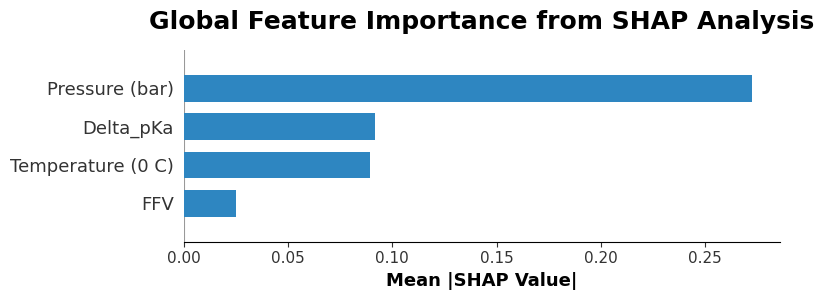

In [37]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    max_display=10,
    color="#2E86C1",
    show=False
)

plt.title(
    "Global Feature Importance from SHAP Analysis",
    fontsize=18,
    fontweight="bold",
    pad=15
)
plt.xlabel(
    "Mean |SHAP Value|",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

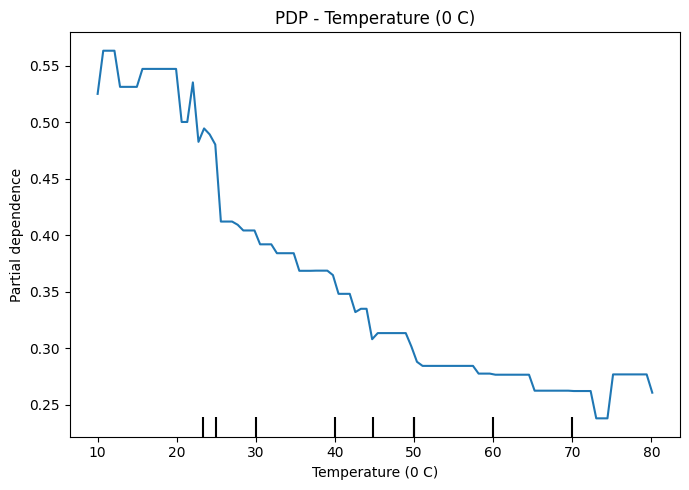

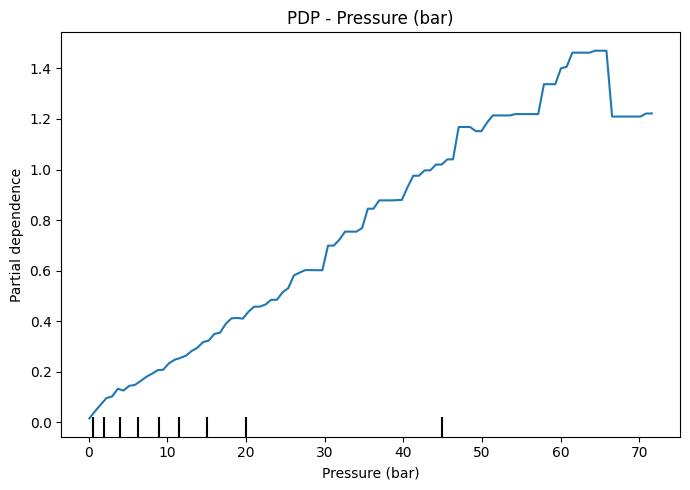

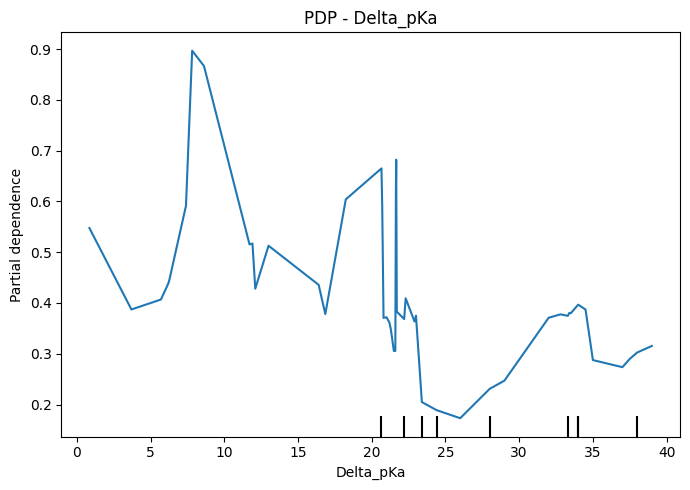

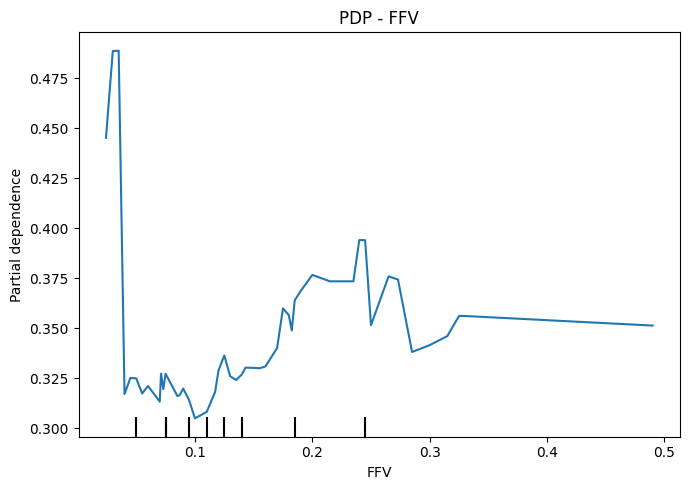

In [38]:
from sklearn.inspection import PartialDependenceDisplay
features_to_plot = X_train.columns.tolist()

for feature in features_to_plot:

    fig, ax = plt.subplots(figsize=(7,5))

    PartialDependenceDisplay.from_estimator(
        model,
        X_train,
        features=[feature],
        ax=ax
    )

    plt.title(f"PDP - {feature}")

    plt.tight_layout()

    plt.show()